# Expansion Analysis

This notebook compares materialized synthetic expansion analyses for pre-electrification, optimized post-electrification, and fixed no-flex post-electrification cases. It shows synthetic-only power-flow stress based on compact summary tables and maps expansion cost envelopes per supplied synthetic grid area.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd


def find_postprocessing_dir() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in (cwd, *cwd.parents):
        if (candidate / "plotting").is_dir() and (candidate / "expansion").is_dir():
            return candidate
    raise FileNotFoundError("Could not find GridExpand/5.postprocessing from the notebook working directory.")


POSTPROCESSING_DIR = find_postprocessing_dir()
if str(POSTPROCESSING_DIR) not in sys.path:
    sys.path.insert(0, str(POSTPROCESSING_DIR))

from expansion import grid_expansion
from plotting import geoplotting
from powerflow.comparison_data import load_synthetic_powerflow_cutoff_profile
from plotting.powerflow_asset_plots import plot_powerflow_asset_cutoff_overview_static
from plotting.powerflow_io import save_plotly_figure
from plotting.powerflow_transformer import (
    plot_transformer_import_distributions_matplotlib,
    transformer_import_distribution_db,
)
from plotting.powerflow_voltage import (
    plot_voltage_deviation_histogram_comparison,
    voltage_deviation_summary_db,
)

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)


In [2]:
# Materialized expansion analyses for the residential TSAM post-electrification comparison.
ANALYSIS_KEYS = {
    "Pre": "full_year_post_electrification_hh_only_tsam_pre",
    "Post-flex": "full_year_post_electrification_hh_only_tsam_post",
    "Post-no-flex": "full_year_post_electrification_hh_only_tsam_post_no_flex",
}

# Keep ANALYSIS_KEY as the default single-stage view for the summary tables below.
ANALYSIS_KEY = ANALYSIS_KEYS["Post-flex"]

# Compact summary runs used for the asset stress comparison.
POWERFLOW_SUMMARY_SPECS = {
    "Pre": {
        "run_name": "baseline_static_hh_only_post_electrification_summary_powerflow",
        "stage": "pre",
    },
    "Post-flex": {
        "run_name": "baseline_static_hh_only_post_electrification_summary_powerflow",
        "stage": "post",
    },
    "Post-no-flex": {
        "run_name": "baseline_static_hh_only_post_electrification_summary_no_flex_powerflow",
        "stage": "post",
    },
}

COMPARISON_COLORS = {
    "Pre": "#2E7D32",
    "Post-flex": "#1F77B4",
    "Post-no-flex": "#D62728",
}
PLZ = None
SCENARIO_ID = None

ASSET_CUTOFF_PERCENTILE = 1.0
OUTPUT_DIR = POSTPROCESSING_DIR / "plotting" / "output" / "expansion"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


## Load Expansion Analysis

The materialized expansion analysis is loaded once here and reused by the following plots. Summary tables are collected at the bottom of the notebook so the visual analysis comes first.


In [3]:

expansion_tables_by_stage = {
    label: grid_expansion.load_expansion_overview(analysis_key=key)
    for label, key in ANALYSIS_KEYS.items()
}

analysis_meta_by_stage = {}
analysis_status_rows = []
for label, tables in expansion_tables_by_stage.items():
    analysis_run = tables["analysis_run"]
    is_available = not analysis_run.empty
    status_row = {
        "stage_label": label,
        "analysis_key": tables["analysis_key"],
        "available": is_available,
        "run_name": None,
        "stage": None,
        "grids_with_expansion_summary": 0,
        "total_cost_eur": pd.NA,
    }
    if is_available:
        meta = analysis_run.iloc[0]
        analysis_meta_by_stage[label] = meta
        status_row.update(
            {
                "run_name": meta["run_name"],
                "stage": meta["stage"],
                "grids_with_expansion_summary": tables["grid_cost_summary"]["grid_case_id"].nunique()
                if not tables["grid_cost_summary"].empty
                else 0,
                "total_cost_eur": float(tables["cost_summary"].iloc[0]["total_cost_eur"])
                if not tables["cost_summary"].empty
                else 0.0,
            }
        )
    analysis_status_rows.append(status_row)

available_analysis_keys = {
    label: ANALYSIS_KEYS[label]
    for label in ANALYSIS_KEYS
    if label in analysis_meta_by_stage
}
missing_analysis_keys = {
    label: ANALYSIS_KEYS[label]
    for label in ANALYSIS_KEYS
    if label not in analysis_meta_by_stage
}
if not available_analysis_keys:
    raise ValueError("None of the configured ANALYSIS_KEYS exist in surrogrid.expansion_analysis_run.")

# Default single-stage tables used by the summary cells below.
default_label_order = ("Post-flex", "Post-no-flex", "Pre")
DEFAULT_ANALYSIS_LABEL = next(
    (label for label in default_label_order if label in available_analysis_keys),
    next(iter(available_analysis_keys)),
)
expansion_tables = expansion_tables_by_stage[DEFAULT_ANALYSIS_LABEL]
analysis_key = expansion_tables["analysis_key"]
ANALYSIS_KEY = analysis_key

if missing_analysis_keys:
    print("Missing materialized expansion analyses; plots below use available analyses only:")
    for label, key in missing_analysis_keys.items():
        print(f"  - {label}: {key}")
print(f"Default summary tables use: {DEFAULT_ANALYSIS_LABEL} ({analysis_key})")

pd.DataFrame(analysis_status_rows)


Default summary tables use: Post-flex (full_year_post_electrification_hh_only_tsam_post)


,stage_label,analysis_key,available,run_name,stage,grids_with_expansion_summary,total_cost_eur
0,Pre,full_year_post_electrification_hh_only_tsam_pre,True,baseline_static_hh_only_post_electrification_s...,pre,74,0.000000e+00
1,Post-flex,full_year_post_electrification_hh_only_tsam_post,True,baseline_static_hh_only_post_electrification_s...,post,73,2.803040e+06
2,Post-no-flex,full_year_post_electrification_hh_only_tsam_po...,True,baseline_static_hh_only_post_electrification_s...,post,74,4.359592e+06


## Expansion Cost Comparison

This plot compares total heuristic expansion costs for the materialized post-electrification cases, split into cable and transformer costs.


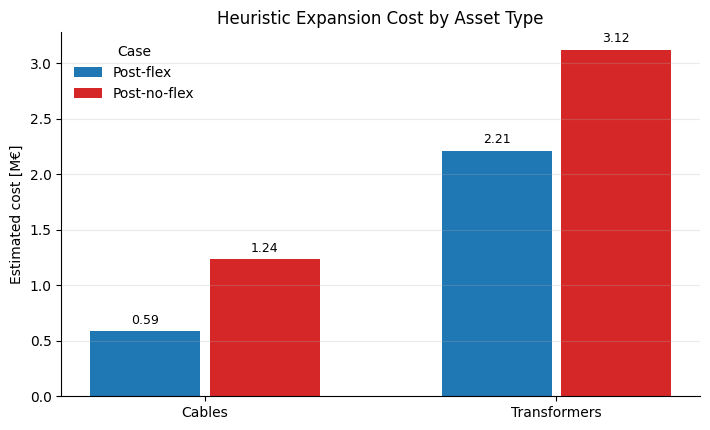

,stage,component,cost_eur
0,Post-flex,Cables,5.890401e+05
1,Post-flex,Transformers,2.214000e+06
2,Post-no-flex,Cables,1.235592e+06
3,Post-no-flex,Transformers,3.124000e+06


In [4]:
cost_rows = []
for label in ("Post-flex", "Post-no-flex"):
    tables = expansion_tables_by_stage.get(label)
    if tables is None or label not in analysis_meta_by_stage or tables["cost_summary"].empty:
        continue
    cost_summary_row = tables["cost_summary"].iloc[0]
    cost_rows.extend(
        [
            {
                "stage": label,
                "component": "Cables",
                "cost_eur": float(cost_summary_row["cable_cost_eur"]),
            },
            {
                "stage": label,
                "component": "Transformers",
                "cost_eur": float(cost_summary_row["transformer_cost_eur"]),
            },
        ]
    )

expansion_cost_comparison = pd.DataFrame(cost_rows)
if expansion_cost_comparison.empty:
    print("No post-electrification expansion cost summaries available yet.")
else:
    plotted_stages = [stage for stage in ("Post-flex", "Post-no-flex") if stage in set(expansion_cost_comparison["stage"])]
    components = ["Cables", "Transformers"]
    fig, ax = plt.subplots(figsize=(7.2, 4.4))
    x = range(len(components))
    bar_width = 0.34
    offsets = {
        stage: (idx - (len(plotted_stages) - 1) / 2) * bar_width
        for idx, stage in enumerate(plotted_stages)
    }
    for stage in plotted_stages:
        values_million_eur = []
        for component in components:
            match = expansion_cost_comparison[
                (expansion_cost_comparison["stage"] == stage)
                & (expansion_cost_comparison["component"] == component)
            ]
            values_million_eur.append(float(match["cost_eur"].sum()) / 1_000_000.0)
        bars = ax.bar(
            [position + offsets[stage] for position in x],
            values_million_eur,
            width=bar_width * 0.92,
            label=stage,
            color=COMPARISON_COLORS.get(stage),
        )
        ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=9)

    ax.set_xticks(list(x))
    ax.set_xticklabels(components)
    ax.set_ylabel("Estimated cost [M€]")
    ax.set_title("Heuristic Expansion Cost by Asset Type")
    ax.legend(frameon=False, title="Case")
    ax.grid(axis="y", alpha=0.25)
    ax.spines[["top", "right"]].set_visible(False)
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "post_flex_no_flex_expansion_cost_bar.svg", bbox_inches="tight")
    fig.savefig(OUTPUT_DIR / "post_flex_no_flex_expansion_cost_bar.png", dpi=220, bbox_inches="tight")
    plt.show()

expansion_cost_comparison


## Synthetic Power-Flow Stress Overview

This reuses the retained-asset cutoff plot from the power-flow comparison workflow, but shows the synthetic runs only. The plot is based on compact summary rows, so it stays lightweight even for many grids.


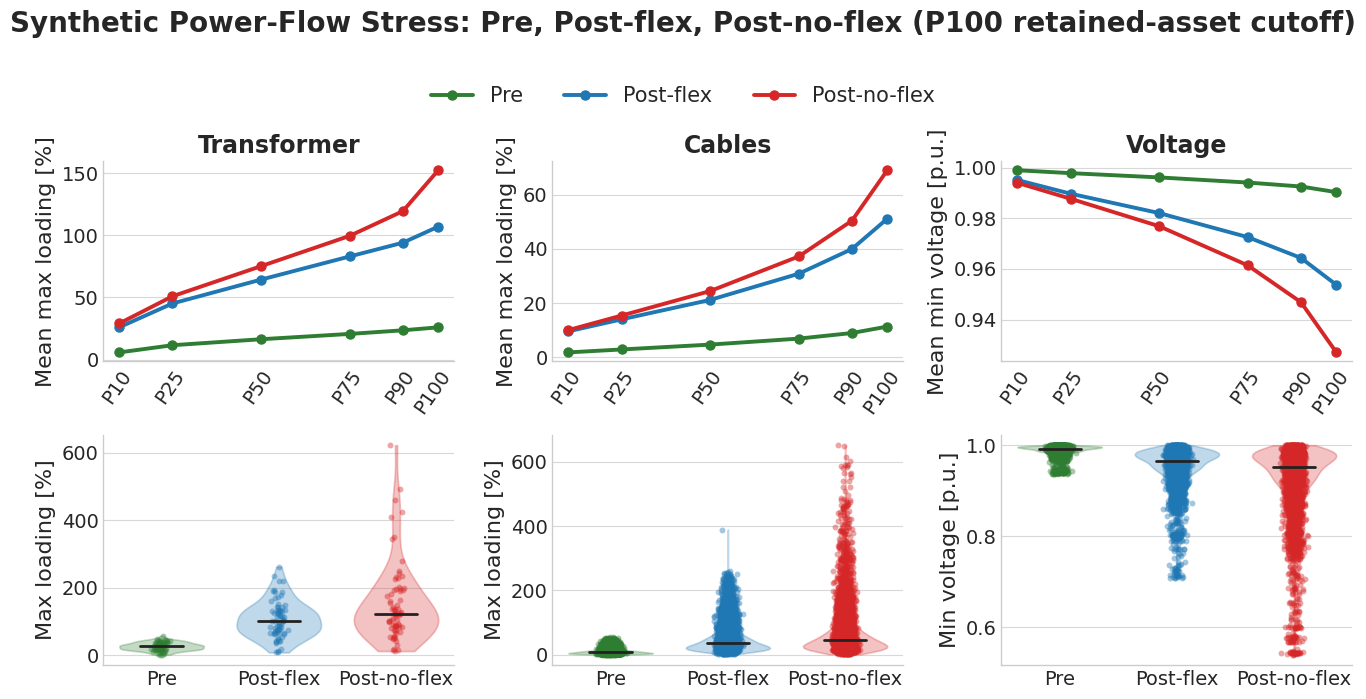

In [5]:

synthetic_summary = pd.DataFrame()
skipped_powerflow_summary_specs = {}
try:
    synthetic_profiles = []
    for label, spec in POWERFLOW_SUMMARY_SPECS.items():
        try:
            profile = load_synthetic_powerflow_cutoff_profile(
                run_name=spec["run_name"],
                stage=spec["stage"],
                scenario_id=SCENARIO_ID,
                plz=PLZ,
            )
        except ValueError as exc:
            skipped_powerflow_summary_specs[label] = str(exc)
            continue
        profile["comparison_stage"] = label
        synthetic_profiles.append(profile)

    if not synthetic_profiles:
        raise ValueError("No configured synthetic compact power-flow summary runs were found.")

    synthetic_profile = pd.concat(synthetic_profiles, ignore_index=True)
    synthetic_summary = (
        synthetic_profile.groupby(["comparison_stage", "metric", "asset_type"], as_index=False)
        .agg(assets=("asset_id", "count"), grids=("grid", "nunique"))
        .sort_values(["comparison_stage", "metric", "asset_type"])
    )
    plotted_stages = list(synthetic_profile["comparison_stage"].drop_duplicates())
    fig = plot_powerflow_asset_cutoff_overview_static(
        synthetic_profile,
        group_col="comparison_stage",
        color_map={label: COMPARISON_COLORS[label] for label in plotted_stages if label in COMPARISON_COLORS},
        asset_cutoff_percentile=ASSET_CUTOFF_PERCENTILE,
        asset_percentiles=(0.10, 0.25, 0.50, 0.75, 0.90, 1.0),
        worst_asset_per_grid=False,
        title="Synthetic Power-Flow Stress: " + ", ".join(plotted_stages),
        save_path=OUTPUT_DIR / "pre_post_flex_no_flex_asset_cutoff_overview",
    )
    plt.show()
    if skipped_powerflow_summary_specs:
        print("Skipped missing compact power-flow summaries:")
        for label, reason in skipped_powerflow_summary_specs.items():
            print(f"  - {label}: {reason}")
except ValueError as exc:
    print(exc)


## Weekly Power-Flow Diagnostics

These plots reuse the raw full power-flow run behind the materialized expansion analysis. The voltage histogram summarizes grid-level voltage extrema over the analyzed week; the transformer import plot shows the weekly import pattern and load-duration curve across the synthetic grid population.


In [6]:

def _meta_filter(meta: pd.Series) -> dict:
    return {
        "run_name": meta["run_name"],
        "stage": meta["stage"],
        "scenario_id": None if pd.isna(meta["scenario_id"]) else int(meta["scenario_id"]),
        "ags": None if pd.isna(meta["ags"]) else int(meta["ags"]),
        "plz": None if pd.isna(meta["plz"]) else int(meta["plz"]),
    }

voltage_summaries = {}
for label, meta in analysis_meta_by_stage.items():
    meta_filter = _meta_filter(meta)
    voltage_summaries[label] = voltage_deviation_summary_db(
        run_name=meta_filter["run_name"],
        stages=(meta_filter["stage"],),
        scenario_id=meta_filter["scenario_id"],
        ags=meta_filter["ags"],
        plz=meta_filter["plz"],
    )

if not voltage_summaries:
    raise ValueError("No available expansion analyses for voltage diagnostics.")

voltage_fig = plot_voltage_deviation_histogram_comparison(
    voltage_summaries,
    lower_limit=0.95,
    upper_limit=1.03,
    show=False,
)
try:
    save_plotly_figure(
        voltage_fig,
        OUTPUT_DIR / "pre_post_flex_no_flex_voltage_deviation_histogram",
        formats=("svg", "png"),
        width=1180,
        height=440,
    )
except RuntimeError as exc:
    print(f"Could not export voltage histogram: {exc}")
display(voltage_fig)


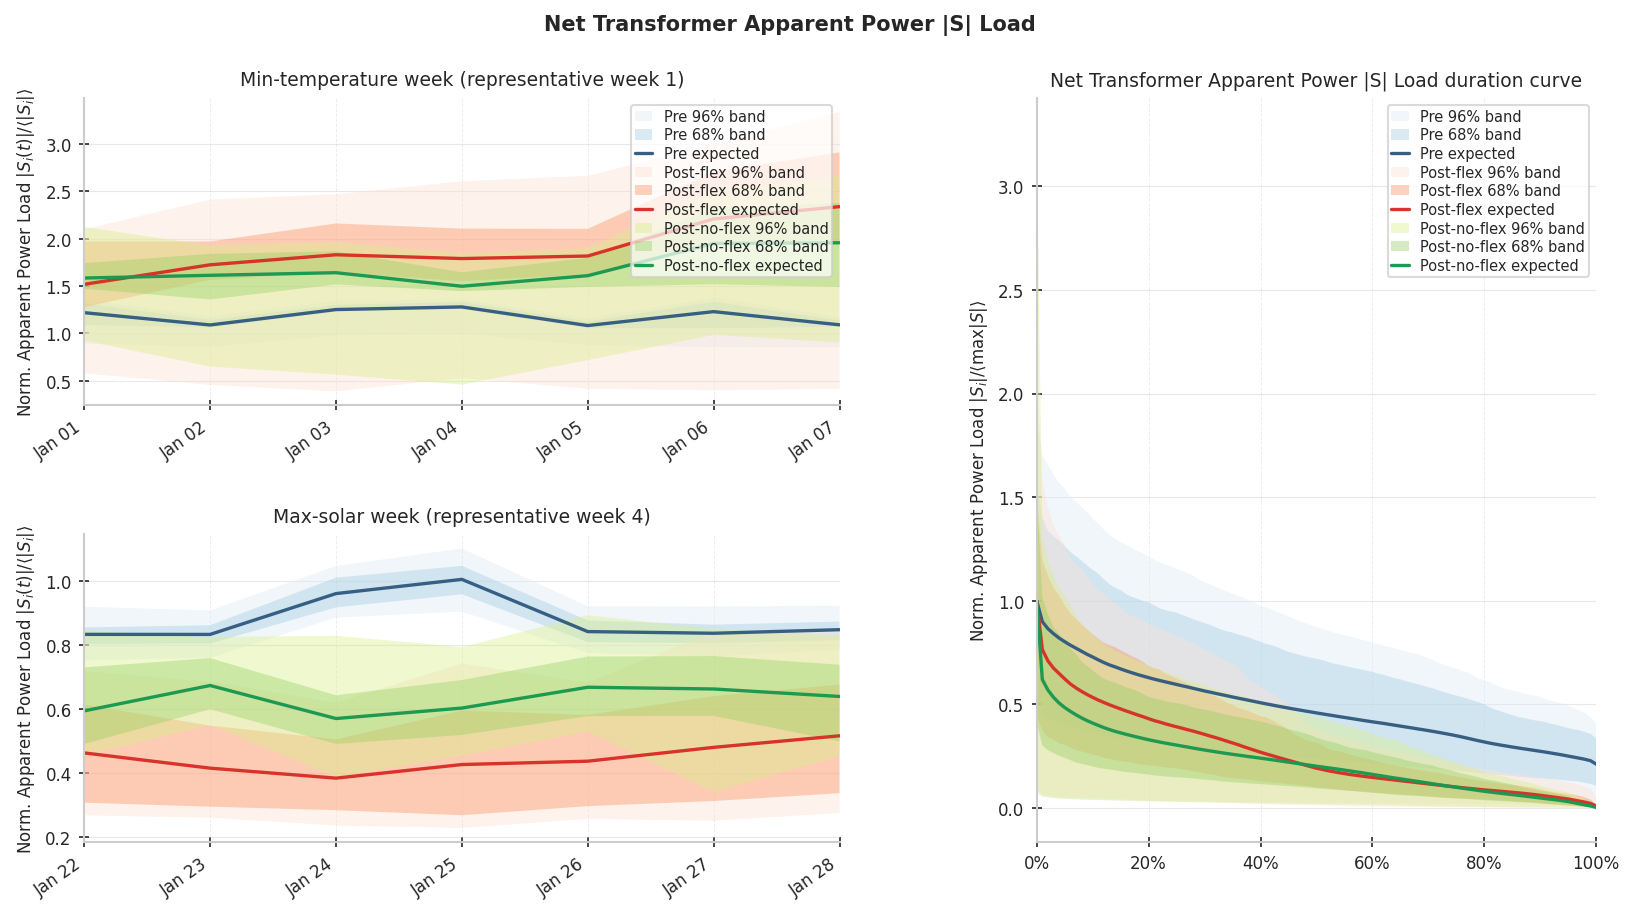

In [7]:

transformer_distributions = []
for label, meta in analysis_meta_by_stage.items():
    meta_filter = _meta_filter(meta)
    distribution = transformer_import_distribution_db(
        run_name=meta_filter["run_name"],
        stage=meta_filter["stage"],
        scenario_id=meta_filter["scenario_id"],
        ags=meta_filter["ags"],
        plz=meta_filter["plz"],
    )
    distribution["comparison_stage"] = label
    transformer_distributions.append(distribution)

if transformer_distributions:
    transformer_distribution = pd.concat(transformer_distributions, ignore_index=True)
    transformer_fig = plot_transformer_import_distributions_matplotlib(
        transformer_distribution,
        metrics=("s",),
        group_col="comparison_stage",
        tsam_week_panels=True,
        show=False,
    )
    transformer_fig.savefig(
        OUTPUT_DIR / "pre_post_flex_no_flex_transformer_import_distributions.svg",
        bbox_inches="tight",
    )
    plt.show()
else:
    transformer_distribution = pd.DataFrame()
    print("No available expansion analyses for transformer diagnostics.")


## Expansion Cost Envelopes

The envelope maps aggregate building/bus points to the supplied synthetic grid areas and color each envelope by the materialized expansion cost. Values are clipped at the selected quantile so one very expensive grid does not dominate the color scale.


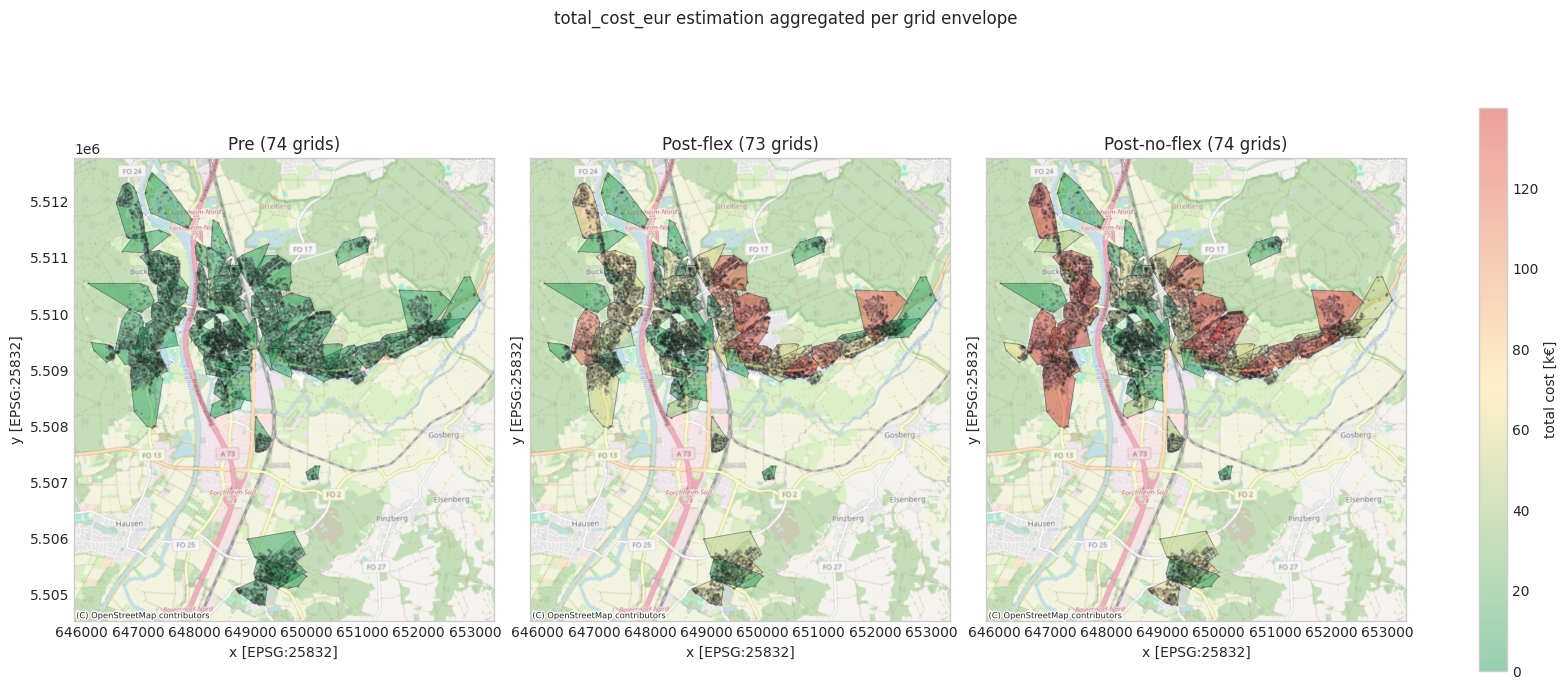

In [8]:

fig, axes, total_envelope_data = geoplotting.plot_synthetic_expansion_envelope_panels(
    analysis_keys=available_analysis_keys,
    value_column="total_cost_eur",  # transformer_cost_eur, cable_cost_eur, total_cost_eur
    clip_quantile=0.95,
    log_scale=False,
    cmap="cost_green_red",
    output_path=OUTPUT_DIR / "pre_post_flex_no_flex_total_cost_envelopes.svg",
)
plt.show()


## Summary Tables

Compact table outputs for the materialized expansion analysis and the plotted diagnostics.


In [9]:
expansion_tables["analysis_run"]


,expansion_analysis_run_id,analysis_key,assumption_key,run_name,stage,scenario_id,ags,plz,created_at,note
0,13,full_year_post_electrification_hh_only_tsam_post,de_lv_heuristic_2026,baseline_static_hh_only_post_electrification_s...,post,None,9474126,None,2026-07-09 12:24:12.770411+00:00,Automatically materialized by synthetic_ags_pi...


In [10]:
expansion_tables["cost_summary"]


,grids_with_line_rows,cable_segments,cable_segments_requiring_expansion,cable_segments_overloaded,cable_cost_eur,transformers,transformers_requiring_expansion,transformers_overloaded,transformer_cost_eur,total_cost_eur
0,73,1078,191,191,589040.112897,73,39,39,2214000.0,2.803040e+06


In [11]:
expansion_tables["grid_cost_summary"].head(10)


,grid_case_id,plz,kcid,bcid,cable_segments,cable_segments_requiring_expansion,cable_cost_eur,max_cable_loading_percent,transformer_rated_power_kva,required_transformer_kva,additional_transformer_kva,transformer_requires_expansion,transformer_cost_eur,transformer_loading_percent,total_cost_eur
0,1894,91301,10,5,26,9,88815.200903,389.285743,630.0,1700.0,1070.0,True,100000.0,262.019141,188815.200903
1,1918,91301,11,3,15,5,40227.911558,259.305659,630.0,1100.0,470.0,True,100000.0,171.907671,140227.911558
2,1890,91301,10,4,16,7,33007.202010,234.923983,630.0,1200.0,570.0,True,100000.0,188.768414,133007.202010
3,1838,91301,7,12,25,8,28745.769506,228.510951,630.0,1400.0,770.0,True,100000.0,218.989036,128745.769506
4,1686,91301,3,3,41,11,28507.475550,241.676934,630.0,1150.0,520.0,True,100000.0,179.402214,128507.475550
5,1898,91301,10,6,20,8,25835.411907,175.816929,630.0,1250.0,620.0,True,100000.0,191.294648,125835.411907
6,1930,91301,11,6,20,7,18831.926819,163.143851,630.0,1200.0,570.0,True,100000.0,186.650999,118831.926819
7,1858,91301,9,5,41,7,18019.189647,152.099762,630.0,1050.0,420.0,True,100000.0,160.798652,118019.189647
8,1834,91301,7,11,18,4,10788.812067,221.213714,630.0,1100.0,470.0,True,100000.0,168.243639,110788.812067
9,1842,91301,8,1,27,8,33415.902027,139.435932,630.0,850.0,220.0,True,48000.0,130.928928,81415.902027


In [12]:
expansion_tables["cable_summary_by_type"]


,visible_std_type,cable_segments,cable_segments_requiring_expansion,length_km,estimated_cost_eur,max_loading_percent
0,NAYY_4_120,943,130,117.626987,278653.377994,259.305659
1,NAYY_4_240,35,14,8.725668,109993.996242,389.285743
2,NAYY_4_185,41,20,7.222127,97658.517614,255.179296
3,NAYY_4_300,28,13,7.316232,78280.716667,211.447832
4,NAYY_4_150,30,14,4.377877,24453.504380,241.676934
5,NAYY_4_50,1,0,0.017310,0.000000,73.928001


In [13]:
expansion_tables["transformer_summary_by_basis"]


,transformer_cost_basis,transformers,transformers_requiring_expansion,additional_transformer_kva,estimated_cost_eur,max_loading_percent
0,station_rebuild_boundary_case_gt_1000kva,9,9,5480.0,900000.0,262.019141
1,all_in_replacement_to_1000kva,13,13,3970.0,624000.0,234.318044
2,all_in_replacement_to_800kva,11,11,1250.0,462000.0,193.392716
3,all_in_replacement_to_630kva,6,6,650.0,228000.0,134.721386
4,none_existing_capacity_sufficient,34,0,0.0,0.0,95.594136


### Power-Flow Stress Input Coverage


In [14]:
synthetic_summary


,comparison_stage,metric,asset_type,assets,grids
0,Post-flex,Cables,cable,39855,73
1,Post-flex,Transformer,transformer,365,73
2,Post-flex,Voltage,bus,29535,73
3,Post-no-flex,Cables,cable,41120,74
4,Post-no-flex,Transformer,transformer,370,74
5,Post-no-flex,Voltage,bus,30635,74
6,Pre,Cables,cable,41120,74
7,Pre,Transformer,transformer,370,74
8,Pre,Voltage,bus,30635,74


### Voltage Summary Sample


In [15]:

if "voltage_summaries" in globals() and voltage_summaries:
    voltage_summary = pd.concat(voltage_summaries.values(), ignore_index=True)
    display(voltage_summary[["grid", "stage", "n_timesteps", "n_buses", "min_vm_pu", "max_vm_pu"]].head())
else:
    print("Run the voltage diagnostics cell first.")


,grid,stage,n_timesteps,n_buses,min_vm_pu,max_vm_pu
0,09474126-91301_1_2,pre,1008,145,0.975362,0.999994
1,09474126-91301_2_2,pre,1008,4,0.993061,0.999982
2,09474126-91301_2_4,pre,1008,53,0.992605,0.999997
3,09474126-91301_1_4,pre,1008,71,0.987660,0.999958
4,09474126-91301_1_3,pre,1008,145,0.972728,0.999995


### Envelope Cost Ranking Sample


In [16]:

if "total_envelope_data" in globals():
    display(total_envelope_data["grid_metrics"].head(5))
else:
    print("Run the expansion cost envelope cell first.")


KeyError: 'grid_metrics'